# geeViz Google Maps Platform Examples

This notebook demonstrates `geeViz.googleMapsLib` — 24 functions for ground-truthing remote sensing analysis using Google Maps Platform APIs.

**Requirements:**
- `pip install geeViz`
- A `.env` file in the geeViz directory with:
  ```
  GEMINI_API_KEY=your_key_here
  GOOGLE_MAPS_PLATFORM_API_KEY=your_key_here
  ```
- For segmentation: `pip install geeViz[segmentation]`

| Section | APIs Used |
|---|---|
| 1. Geocoding | Geocoding, Reverse Geocoding, Address Validation |
| 2. Street View | Street View Static, Panorama Stitching |
| 3. Places | Places (New), Place Photos |
| 4. Environment | Elevation, Air Quality, Solar, Timezone |
| 5. AI Analysis | Gemini Interpretation, Object Detection |
| 6. Segmentation | SegFormer Semantic Segmentation |
| 7. Rigorous Image Inventory | `inventory_area` — design-based sampling + Gemini interpretation + stats |


[![github](https://img.shields.io/badge/-see%20sources-white?logo=github&labelColor=555)](https://github.com/gee-community/geeviz/blob/master/examples/googleMapsLib_examples.ipynb) 
[![github](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gee-community/geeViz/blob/master/examples/googleMapsLib_examples.ipynb)

In [1]:
import geeViz.googleMapsLib as gm
from IPython.display import display, HTML, Image as IPImage, Markdown
import json, os, time

output_dir = os.path.join(os.path.dirname(os.getcwd()), "examples", "outputs", "google_maps")
os.makedirs(output_dir, exist_ok=True)
print(f"Output: {output_dir}")
print(f"Maps key: {'set' if gm._get_api_key() else 'MISSING'}")

Output: c:\RCR\geeVizBuilder\geeViz\examples\outputs\google_maps
Maps key: set


---
## 1. Geocoding

Convert addresses to coordinates and back.

In [2]:
# Forward geocode
loc = gm.geocode("100 S State St, Salt Lake City, UT")
print(f"Address: {loc['formatted_address']}")
print(f"Coords: {loc['lat']}, {loc['lon']}")
print(f"Accuracy: {loc['location_type']}")

# Reverse geocode
rev = gm.reverse_geocode(loc['lon'], loc['lat'])
print(f"\nReverse: {rev['formatted_address']}")

# Address validation
val = gm.validate_address("3000 asdf way slc ut")
if val:
    print(f"\nValidated: {val['formatted_address']}")
    print(f"Complete: {val['verdict']['address_complete']}")
    if val.get('usps_data'):
        print(f"USPS: {val['usps_data']['standardized_address'].get('firstAddressLine')}")

Address: State St & 100 S, Salt Lake City, UT 84138, USA
Coords: 40.7671365, -111.888139
Accuracy: GEOMETRIC_CENTER

Reverse: 95 S State St Suite 900, Salt Lake City, UT 84111, USA

Validated: 3000 asdf way, Salt Lake City, UT, USA
Complete: False
USPS: 3000 ASDF WAY


---
## 2. Street View

Fetch Street View imagery — single frames, cardinal directions, stitched panoramas.

Status: OK, Date: 2025-08


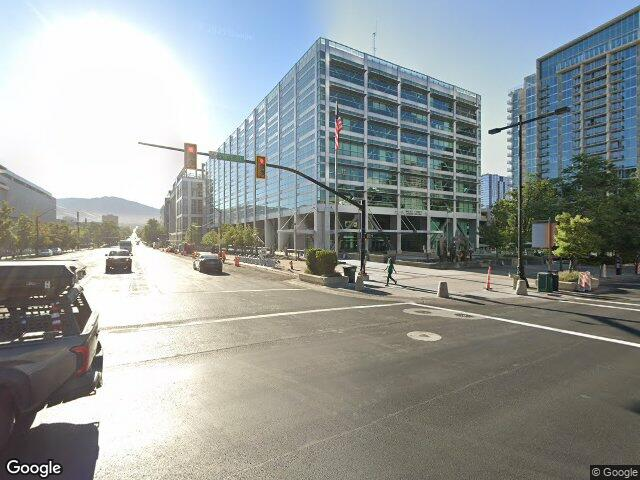

Single frame: 61,565 bytes


In [3]:
# Check coverage
meta = gm.streetview_metadata(loc['lon'], loc['lat'])
print(f"Status: {meta['status']}, Date: {meta.get('date')}")

# Single image
img = gm.streetview_image(loc['lon'], loc['lat'], heading=120)
if img:
    display(IPImage(data=img, width=600))
    print(f"Single frame: {len(img):,} bytes")

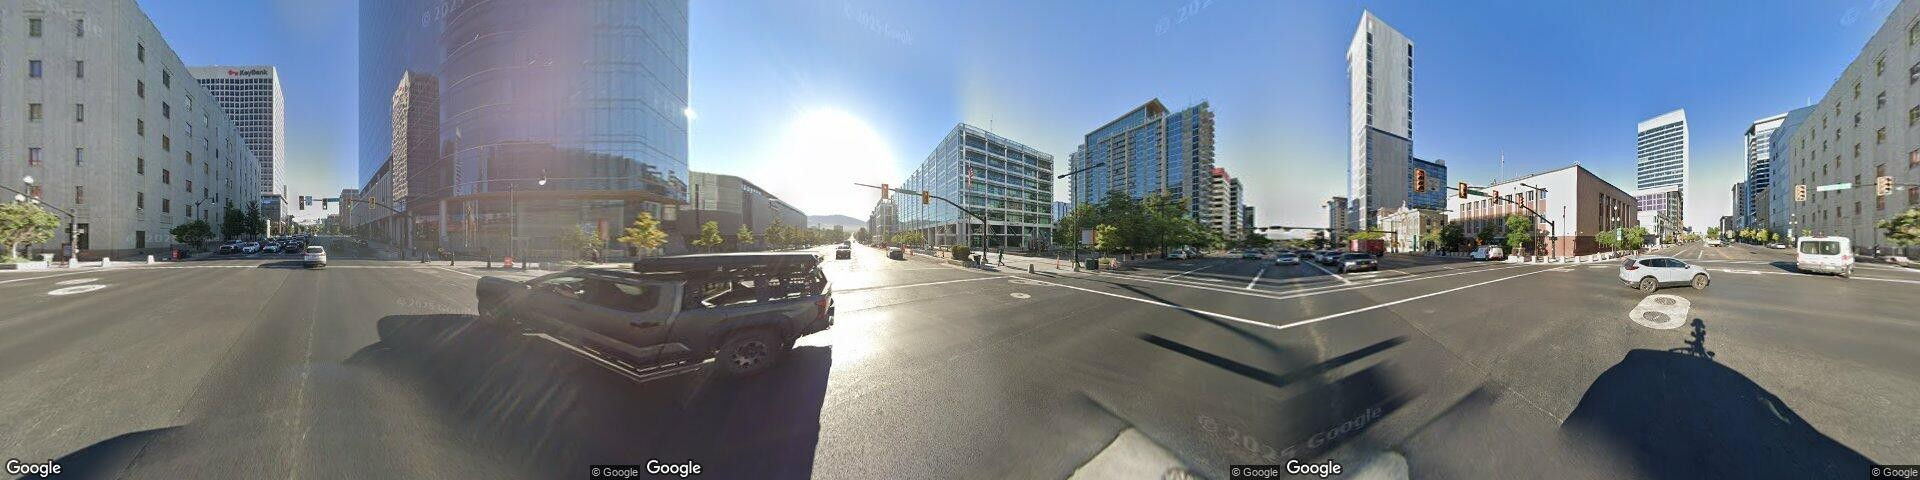

360° panorama: 194,109 bytes


In [4]:
# 360° stitched panorama
pano = gm.streetview_panorama(loc['lon'], loc['lat'], heading=120, fov=360)
if pano:
    display(IPImage(data=pano, width=900))
    print(f"360° panorama: {len(pano):,} bytes")


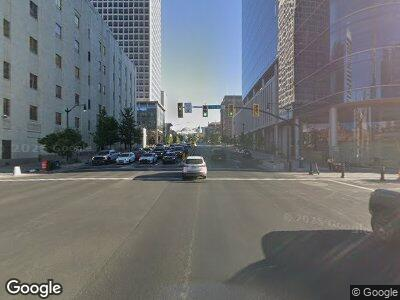
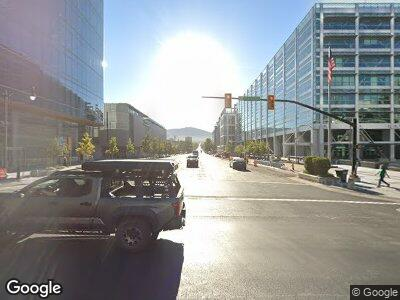
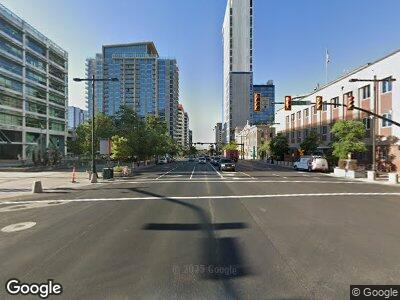
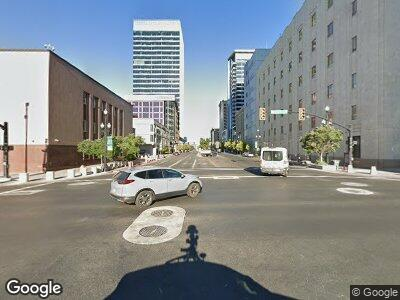

In [5]:
# HTML panel with cardinal directions
html = gm.streetview_html(loc['lon'], loc['lat'])
if html:
    display(HTML(html))

---
## 3. Places

Search for places near a location.

In [6]:
# Text search
places = gm.search_places("coffee shop", lat=loc['lat'], lon=loc['lon'], radius=2000)
print(f"Found {len(places)} coffee shops:\n")
for p in places[:5]:
    rating = f" ({p['rating']}★)" if p.get('rating') else ""
    print(f"  {p['display_name']}{rating}: {p['address']}")

# Nearby search
parks = gm.search_nearby(loc['lat'], loc['lon'], radius=3000, included_types=["park"])
print(f"\nFound {len(parks)} parks nearby")
for p in parks[:3]:
    print(f"  {p['display_name']}: {p['address']}")

Found 10 coffee shops:

  JJ Coffee Co (4.8★): 330 E 400 S Ste 102, Salt Lake City, UT 84111, USA
  Buzzed Coffeehouse (5★): 265 S State St Ste 113, Salt Lake City, UT 84111, USA
  The People's Coffee (4.6★): 177 E 200 S, Salt Lake City, UT 84111, USA
  Three Pines Coffee (4.5★): 165 S Main St, Salt Lake City, UT 84111, USA
  District Coffee Co. (4.6★): 206 N 200 W #1, Salt Lake City, UT 84103, USA

Found 10 parks nearby
  Liberty Park: 600 Harvey Milk Blvd, Salt Lake City, UT 84105, USA
  Capitol Hill, Salt Lake City, UT: Utah State Capitol, Salt Lake City, UT 84103, USA
  Pioneer Park: 350 S 300 W, Salt Lake City, UT 84101, USA


---
## 4. Environment

Elevation, air quality, solar potential, and timezone.

In [7]:
# Elevation
elev = gm.get_elevation(loc['lon'], loc['lat'])
print(f"Elevation: {elev:.0f} m ({elev * 3.28084:.0f} ft)")

# Elevation profile
profile = gm.get_elevation_along_path(
    [(-111.89, 40.77), (-111.80, 40.68)],  # SLC downtown to Wasatch foothills
    samples=10,
)
print(f"\nElevation profile ({len(profile)} points):")
for p in profile:
    print(f"  ({p['lat']:.4f}, {p['lon']:.4f}): {p['elevation']:.0f} m")

Elevation: 1315 m (4313 ft)

Elevation profile (10 points):
  (40.7700, -111.8900): 1324 m
  (40.7600, -111.8800): 1304 m
  (40.7500, -111.8700): 1306 m
  (40.7400, -111.8600): 1322 m
  (40.7300, -111.8500): 1354 m
  (40.7200, -111.8400): 1370 m
  (40.7100, -111.8300): 1387 m
  (40.7000, -111.8200): 1411 m
  (40.6900, -111.8100): 1456 m
  (40.6800, -111.8000): 1503 m


AQI: 47 — Moderate air quality
Dominant pollutant: o3

Solar potential:
  Max panels: 476
  Annual output: 272,665 kWh
  Roof area: 1387 m²


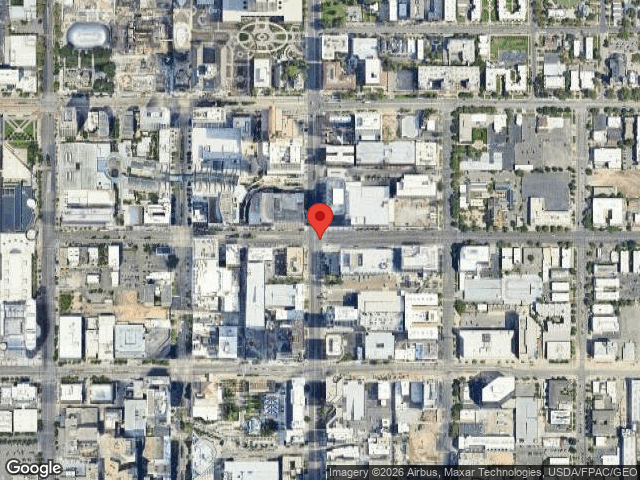


Timezone: America/Denver (Mountain Daylight Time)


In [8]:
# Air quality
aq = gm.get_air_quality(loc['lon'], loc['lat'])
if aq:
    print(f"AQI: {aq['aqi']} — {aq['category']}")
    print(f"Dominant pollutant: {aq['dominant_pollutant']}")

# Solar potential
solar = gm.get_solar_insights(loc['lon'], loc['lat'])
if solar:
    print(f"\nSolar potential:")
    print(f"  Max panels: {solar['max_panels']}")
    print(f"  Annual output: {solar['max_annual_kwh']:,.0f} kWh")
    print(f"  Roof area: {solar['roof_area_m2']:.0f} m²")
# Show static map of the location
static_map = gm.get_static_map(loc['lon'], loc['lat'],zoom=16,markers=[(loc['lon'],loc['lat'])])
if static_map:
    display(IPImage(data=static_map, width=600))

# Timezone
tz = gm.get_timezone(loc['lon'], loc['lat'])
if tz:
    print(f"\nTimezone: {tz['timezone_id']} ({tz['timezone_name']})")

---
## 5. AI Analysis (Gemini)

Use Gemini to interpret and label Street View imagery. Requires `GEMINI_API_KEY`.

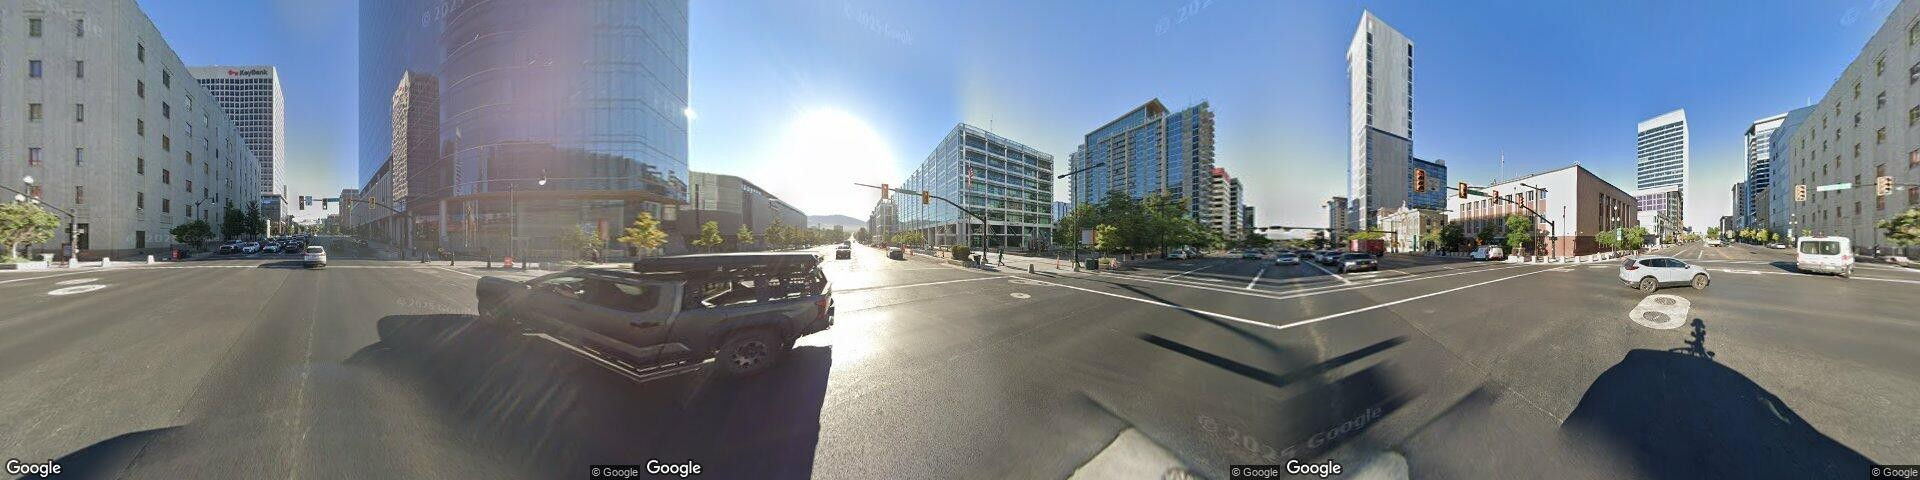

Interpreting Street View panorama with Gemini...


This panoramic street view captures the wide intersection of State Street and 100 South in downtown Salt Lake City, Utah. The surrounding area is characterized by high-density commercial and office land use, featuring a mix of towering modern glass skyscrapers, contemporary mid-rise offices, and classic stone-faced municipal or commercial buildings. The infrastructure consists of multi-lane asphalt roadways with painted lane markings, concrete sidewalks, traffic signals, and decorative streetlights, with young deciduous street trees lining the sidewalks under a clear, bright sky.


*   **Impervious Surface (Roads, sidewalks, buildings)**: ~75%
*   **Sky**: ~22%
*   **Vegetation (Street trees)**: ~3%
*   **Bare Soil**: 0%

| Object | Count | Notes |
| :--- | :--- | :--- |
| Dark pickup truck | 1 | Located in the left-foreground with a prominent bed rack |
| White SUV | 1 | Driving on the right side of the intersection |
| White delivery van | 1 | Visible on the far right street |
| Distant vehicles | ~15 | Various cars and SUVs driving or parked along the distant streets |
| Curved glass skyscraper | 1 | Large modern office building on the left-center |
| Classic stone multi-story building | 2 | One on the far left, one on the far right |
| Modern grid-facade office building | 1 | Located in the center background |
| Blue glass high-rise | 1 | Located in the center-right background |
| Tall white skyscraper | 1 | Modern high-rise in the right-center background |
| Distant office tower | 1 | KeyBank building visible in the far left background |
| Traffic light poles/gantries | 4 | Located at the intersection corners holding traffic signals |
| Streetlight poles | ~8 | Decorative black poles lining the sidewalks |
| Deciduous street trees | ~18 | Planted in grates along the sidewalks |
| Mountains | 1 | Visible in the far distance down the central street corridor |


Model: gemini-3.5-flash  |  temp: 0.3  |  mode: streetview
Input tokens: 1262 (text=206, image=1056)
Output tokens: 473  thoughts: 1497  total: 3232


In [9]:
display(IPImage(data=pano, width=900))
print('Interpreting Street View panorama with Gemini...')
# `mode` picks a prompt tuned for the view type. "streetview" is the
# default (shown here for clarity); other modes are demonstrated below.
result = gm.interpret_image(
    pano,
    mode="streetview",
    context=f"{loc['formatted_address']}. Downtown Salt Lake City.",
)
display(Markdown(result['description']))
display(Markdown(result['object_counts']))

# NEW: metadata block — model, temperature, and per-modality token counts.
meta = result['metadata']
print(f"\nModel: {meta['model']}  |  temp: {meta['temperature']}  |  mode: {meta['mode']}")
print(f"Input tokens: {meta['input_tokens']} "
      f"(text={meta['input_text_tokens']}, image={meta['input_image_tokens']})")
print(f"Output tokens: {meta['output_tokens']}  "
      f"thoughts: {meta['thought_tokens']}  total: {meta['total_tokens']}")

### 5b. Other view types — the `mode` parameter

`interpret_image` accepts a `mode` argument that picks a prompt tuned for that view type. Available modes: `streetview` (default), `satellite-map`, `hybrid-map`, `roadmap`, `terrain`.

The non-streetview modes tell Gemini the image is a top-down (nadir) view and ask for roof-visible features (rooftops, tree crowns, parking, driveways) instead of ground-perspective ones (people, signs, mailboxes), which aren't reliably resolvable from above.


=== mode='satellite-map' (maptype=satellite, zoom=17) ===


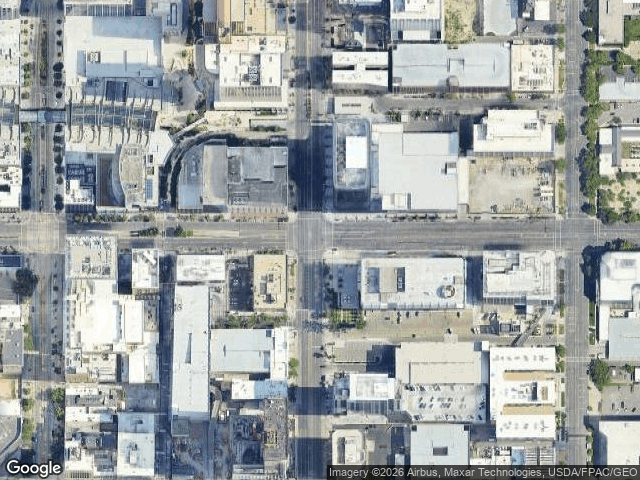

This satellite image depicts a highly developed, high-density commercial and civic downtown area in Salt Lake City, Utah, centered around the intersection of State Street and 100 South. The urban landscape is defined by a rigid grid road network of wide multi-lane streets, large commercial office buildings, retail complexes, and parking structures. Notable features include a prominent pedestrian skybridge on the upper left and scattered street-level tree canopies lining the sidewalks.

---


---


*   **Impervious Surface (Roofs, roads, parking lots, plazas)**: 93%
*   **Tree Canopy**: 5%
*   **Grass / Low Vegetation**: 2%
*   **Bare Soil / Agriculture**: 0%
*   **Water**: 0%

| Object | Count | Notes |
| :--- | :--- | :--- |
| **Commercial/Office Buildings (Rooftops)** | ~32 | Large, flat-roofed structures of varying heights, including retail complexes and office towers. |
| **Major Road Corridors** | 4 | Wide multi-lane streets forming a grid (State St, 100 S, Main St on the left, and 200 East on the right). |
| **Surface Parking Lots / Exposed Decks** | 5 | Flat asphalt lots or top levels of parking structures with visible parked vehicles. |
| **Individual Tree Crowns / Canopy Patches** | ~45 | Small green street trees planted along sidewalks and within plazas. |
| **Pedestrian Skybridge** | 1 | Elevated walkway crossing the street in the upper-left quadrant. |

  model=gemini-3.5-flash  in=1341 (text=277, image=1064)  out=369  thoughts=1116  total=2826

=== mode='hybrid-map' (maptype=hybrid, zoom=17) ===


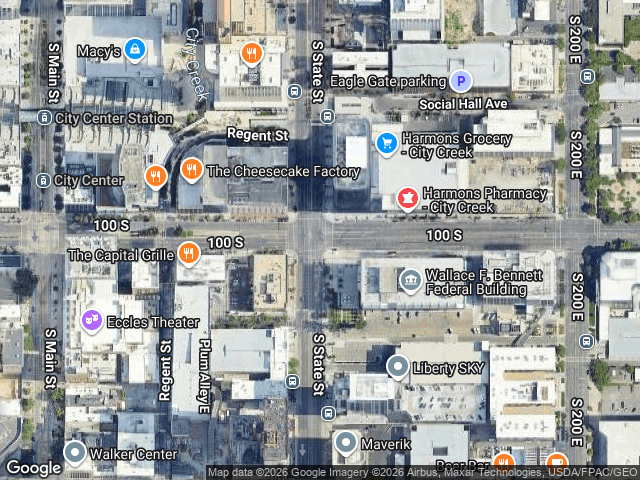

This nadir aerial view displays a highly developed, high-density downtown urban district in Salt Lake City, Utah, centered around the intersection of S State St and 100 S. The dominant land use is commercial, civic, and mixed-use residential, featuring prominent landmarks such as the Eccles Theater, the Wallace F. Bennett Federal Building, and Harmons Grocery. The area is organized on a strict grid-based road network with wide multi-lane streets (State St, Main St, 200 E, and 100 S) interspersed with smaller pedestrian ways and alleys like Regent Street.

---


---


*   **Impervious surface**: 93% (comprising rooftops, multi-lane asphalt roads, concrete sidewalks, plazas, and parking structures)
*   **Tree canopy**: 5% (consisting of managed street trees and plaza landscaping)
*   **Grass/low vegetation**: 2% (limited to small landscaped planter beds)
*   **Bare soil/agriculture**: 0%
*   **Water**: 0%

| Object | Count | Notes |
| :--- | :--- | :--- |
| **Rooftops** | 42 | High-density commercial, residential, and civic building roofs of varying shapes and colors. |
| **Road segments** | 16 | Distinct asphalt street segments divided by intersections (including Main St, State St, 200 E, 100 S, and alleys). |
| **Parking lots** | 4 | Includes the upper deck of the Eagle Gate parking garage and small surface loading/parking areas. |
| **Tree canopy patches** | 12 | Small clusters and rows of street trees planted along sidewalks and plazas. |
| **Water** | 0 | No open bodies of water are visible. |
| **Macy's** | 1 | Labeled retail store at the top left. |
| **City Center Station** | 1 | Labeled transit station on S Main St. |
| **City Center** | 1 | Labeled shopping/transit area on S Main St. |
| **The Capital Grille** | 1 | Labeled restaurant on 100 S. |
| **Eccles Theater** | 1 | Labeled performing arts theater on Regent St. |
| **Walker Center** | 1 | Labeled landmark building at the bottom left. |
| **The Cheesecake Factory** | 1 | Labeled restaurant near Regent St. |
| **Harmons Grocery - City Creek** | 1 | Labeled grocery store on Social Hall Ave. |
| **Harmons Pharmacy - City Creek** | 1 | Labeled pharmacy on 100 S. |
| **Eagle Gate parking** | 1 | Labeled parking structure near Social Hall Ave. |
| **Wallace F. Bennett Federal Building** | 1 | Labeled government building on 100 S. |
| **Liberty SKY** | 1 | Labeled apartment building near S State St. |
| **Maverik** | 1 | Labeled convenience store/gas station brand at the bottom center. |
| **Beer Bar** | 1 | Labeled bar partially visible at the bottom right. |

  model=gemini-3.5-flash  in=1298 (text=234, image=1064)  out=718  thoughts=2170  total=4186

=== mode='roadmap' (maptype=roadmap, zoom=14) ===


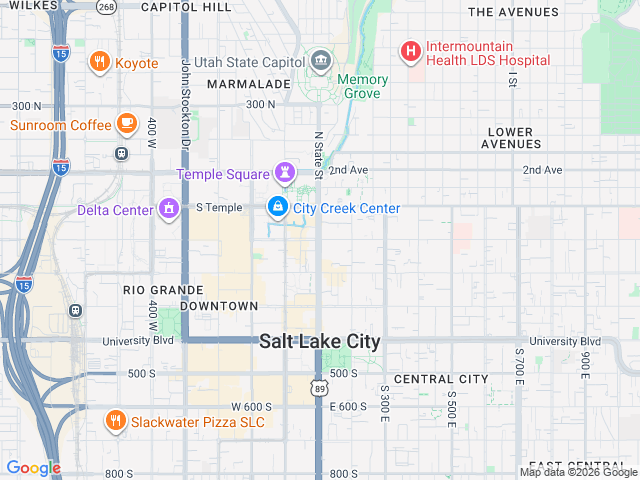

This map depicts the downtown and surrounding neighborhoods of Salt Lake City, Utah, characterized by a highly structured, wide-grid street system. The dominant land use is built-up urban space, represented by light gray residential/commercial blocks and a distinct yellow/tan tint highlighting the commercial core of Downtown and Temple Square. The road hierarchy is clearly defined, featuring Interstate 15 running vertically along the western edge, major arterials like State Street (US-89) and University Boulevard cutting through the center, and a dense network of local gridded streets.

---


---


*   **Road Right-of-Way**: ~25% (Salt Lake City's famously wide streets and the multi-lane I-15 corridor occupy a significant portion of the map area).
*   **Park / Green Space**: ~8% (Primarily Memory Grove, the Utah State Capitol grounds, and a park block in the upper-right corner).
*   **Water**: <1% (Limited to the thin blue line representing City Creek).
*   **Built-up (Residential/Commercial)**: ~67% (The vast majority of the gridded blocks containing commercial downtown zones and residential neighborhoods).

| Feature | Count | Notes |
| :--- | :--- | :--- |
| **Labeled Highways** | 3 | Interstate 15 (I-15), US Route 89 (State St), and State Route 268. |
| **Labeled Arterials** | 5 | State St (N State St), S Temple, University Blvd, 400 W, and John Stockton Dr. |
| **Labeled Local Streets** | 10 | 300 N, 2nd Ave, I St, 500 S, W 600 S, 800 S, S 300 E, S 500 E, S 700 E, and 900 E. |
| **Intersections** | Multiple | Highly regular grid pattern with dozens of major intersections (e.g., State St & University Blvd). |
| **Cul-de-sacs** | 0 | None visible due to the strict gridiron street plan. |
| **Labeled Parks** | 1 | Memory Grove (green-shaded canyon park in the upper-middle section). |
| **Labeled Water Bodies** | 0 | City Creek is represented by a blue line flowing through Memory Grove, but it is not text-labeled. |
| **Labeled Businesses / POIs** | 8 | Utah State Capitol, Temple Square, Delta Center, City Creek Center, Intermountain Health LDS Hospital, Koyote, Sunroom Coffee, and Slackwater Pizza SLC. |
| **Neighborhoods / Districts** | 9 | Wilkes, Capitol Hill, Marmalade, The Avenues, Lower Avenues, Rio Grande, Downtown, Central City, and East Central. |

  model=gemini-3.5-flash  in=1319 (text=255, image=1064)  out=638  thoughts=1682  total=3639

=== mode='terrain' (maptype=terrain, zoom=11) ===


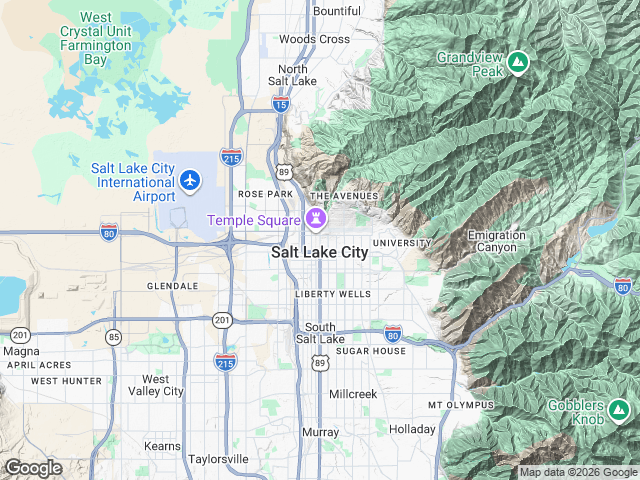

The map displays a dramatic transition between the flat, low-lying Salt Lake Valley in the west and the rugged, steep peaks of the Wasatch Range in the east. The valley floor exhibits very gentle, near-flat relief that accommodates extensive urban development, while the mountains to the east show high, steep relief carved by deep canyons. Notable drainage and water features include Farmington Bay (part of the Great Salt Lake) visible in the northwestern corner of the map.

---


---

* **Relative Elevation Range**: **High relief**. The terrain transitions sharply from the flat valley floor (approximately 4,200 feet above sea level) to rugged mountain peaks exceeding 9,000–10,000 feet (such as Gobblers Knob and Grandview Peak), representing a vertical relief of over 5,000 feet.
* **Dominant Slope Orientation**: The overall mountain front slopes steeply to the **west/southwest** down into the Salt Lake Valley. Within the mountains, the slopes are highly dissected and **mixed**, with canyon walls (such as those along Emigration Canyon) presenting distinct north- and south-facing aspects.

| Feature | Count | Notes |
| :--- | :---: | :--- |
| **Named Peaks / Ridges** | 3 | Grandview Peak, Gobblers Knob (both marked with green icons), and Mt Olympus. |
| **Named Valleys / Canyons** | 1 | Emigration Canyon. |
| **Rivers / Lakes / Water Bodies** | 1 | West Crystal Unit Farmington Bay (Great Salt Lake). |
| **Labeled Roads** | 6 | Major highways: Interstate 15, Interstate 80, Interstate 215, US Route 89, State Route 201, and State Route 85. |
| **Labeled Populated Places / Neighborhoods** | 20 | Salt Lake City, South Salt Lake, West Valley City, Bountiful, Woods Cross, North Salt Lake, Murray, Taylorsville, Kearns, Millcreek, Holladay, Magna, and local neighborhoods/districts (Rose Park, The Avenues, University, Glendale, Liberty Wells, Sugar House, April Acres, West Hunter). |

  model=gemini-3.5-flash  in=1290 (text=226, image=1064)  out=491  thoughts=1388  total=3169


In [10]:
# Try each non-streetview mode against a static map at the same point.
# Zoom is picked per mode to show relevant features.
_STATIC_DEMOS = [
    ("satellite-map", "satellite", 17),
    ("hybrid-map",    "hybrid",    17),
    ("roadmap",       "roadmap",   14),
    ("terrain",       "terrain",   11),
]
for mode, maptype, zoom in _STATIC_DEMOS:
    img = gm.get_static_map(
        loc['lon'], loc['lat'],
        zoom=zoom, size="640x480", maptype=maptype,
    )
    if img is None:
        print(f"[{mode}] fetch failed"); continue
    print(f"\n=== mode={mode!r} (maptype={maptype}, zoom={zoom}) ===")
    display(IPImage(data=img, width=640))
    r = gm.interpret_image(
        img, mode=mode,
        context=f"{loc['formatted_address']}. Downtown Salt Lake City.",
    )
    display(Markdown(r['description']))
    display(Markdown(r['object_counts']))
    m = r['metadata']
    print(f"  model={m['model']}  in={m['input_tokens']} "
          f"(text={m['input_text_tokens']}, image={m['input_image_tokens']})  "
          f"out={m['output_tokens']}  thoughts={m['thought_tokens']}  "
          f"total={m['total_tokens']}")


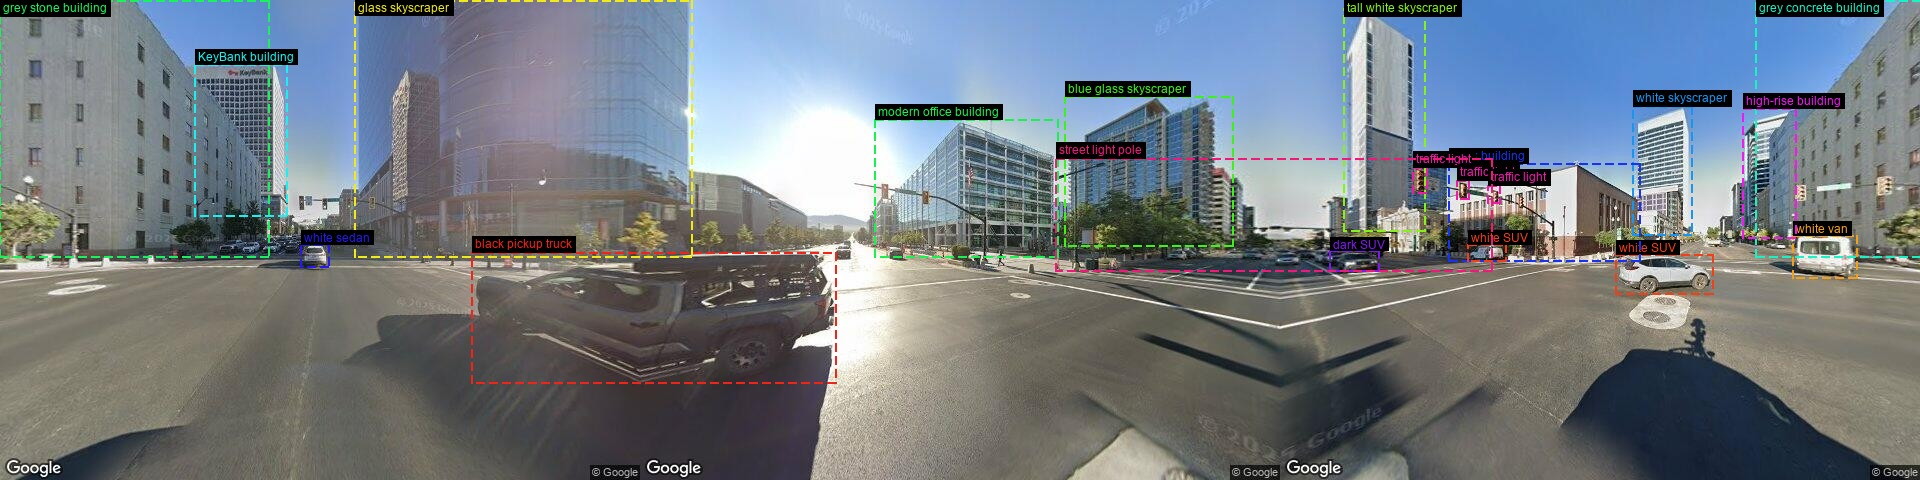

Detected 20 objects at 95 S State St Suite 900, Salt Lake City, UT 84111, USA


| # | Object | Box |
|---|---|---|
| 1 | black pickup truck | (472,252,835,383) |
| 2 | white SUV | (1616,254,1712,294) |
| 3 | white van | (1793,235,1856,278) |
| 4 | glass skyscraper | (355,0,691,257) |
| 5 | tall white skyscraper | (1344,8,1424,231) |
| 6 | blue glass skyscraper | (1065,96,1232,246) |
| 7 | modern office building | (875,119,1057,257) |
| 8 | grey stone building | (0,0,268,257) |
| 9 | grey concrete building | (1756,0,1920,257) |
| 10 | KeyBank building | (195,64,286,216) |
| 11 | white skyscraper | (1633,106,1691,235) |
| 12 | brick building | (1449,163,1639,261) |
| 13 | white sedan | (301,244,328,267) |
| 14 | dark SUV | (1330,250,1378,271) |
| 15 | white SUV | (1468,244,1505,261) |
| 16 | high-rise building | (1743,108,1795,238) |
| 17 | traffic light | (1413,167,1426,193) |
| 18 | traffic light | (1457,180,1468,199) |
| 19 | traffic light | (1488,185,1499,203) |
| 20 | street light pole | (1056,158,1491,271) |

Model: gemini-3.5-flash  in=1225 out=715  total=3634


In [11]:
# Label objects with bounding boxes.
# `label_streetview` is now a thin wrapper around `label_image` — it fetches
# the panorama, reverse-geocodes for the prompt header, then hands off.
labeled = gm.label_streetview(
    loc['lon'], loc['lat'],
    heading=120, fov=360,
    max_labels=20,
)
if labeled:
    display(IPImage(data=labeled['image'], width=900))
    print(f"Detected {len(labeled['detections'])} objects at {labeled['location']}")
    display(Markdown(labeled['summary']))
    m = labeled['metadata']
    print(f"Model: {m['model']}  in={m['input_tokens']} "
          f"out={m['output_tokens']}  total={m['total_tokens']}")


### 5c. `label_image` — label any image (any view type)

`label_image` takes bytes directly, so it works for arbitrary imagery — a satellite tile, an oblique aerial, or a user-supplied photo. `label_streetview` is now a thin lon/lat convenience wrapper around it.

The `mode` argument matches `interpret_image` — pick `streetview` (default), `satellite-map`, `hybrid-map`, `roadmap`, or `terrain`, and Gemini gets a header + detection prompt tuned for that view type. Nadir modes explicitly steer the model toward roof-visible features (rooftops, driveways, tree crowns, parking) and away from small ground-level things that aren't reliably resolvable from above.

Returned `metadata` includes a `parse_error` field. Gemini's JSON mode occasionally emits malformed output; the parser falls back through repair rules → regex extraction before giving up. If `detections` is empty, check `metadata['parse_error']` to see why.

In [ ]:
# Nadir labelling: fetch a satellite tile, hand the bytes to label_image
# with mode="satellite-map" — same prompt registry that interpret_image uses.
sat = gm.get_static_map(
    loc['lon'], loc['lat'],
    zoom=18, size="640x480", maptype="satellite",
)
labeled_sat = gm.label_image(
    sat,
    mode="satellite-map",
    location_str=loc['formatted_address'],
    max_labels=20,
)
if labeled_sat:
    display(IPImage(data=labeled_sat['image'], width=640))
    n = labeled_sat['metadata']['detections_count']
    print(f"Detected {n} rooftop-visible features")
    display(Markdown(labeled_sat['summary']))
    m = labeled_sat['metadata']
    print(f"Model: {m['model']}  mode={m['mode']}  in={m['input_tokens']} "
          f"out={m['output_tokens']}  total={m['total_tokens']}")
    if m.get('parse_error'):
        print(f"  parse fallback used: {m['parse_error']}")

---
## 6. Semantic Segmentation

Pixel-level land cover classification via SegFormer. Requires `pip install geeViz[segmentation]` for `torch` + `transformers`.

`segment_image` accepts a `mode` argument that picks a preset — the class taxonomy, broad-category rollup, and colour palette. Modes:

| mode | orientation | taxonomy | classes | default checkpoint |
|---|---|---|---|---|
| `streetview` (default) | ground | ADE20K | 150 | NVIDIA official — auto |
| `aerial-urban` | nadir | ISPRS Potsdam | 6 (impervious / building / low_veg / tree / car / clutter) | user `model_id=` |
| `aerial-landcover` | nadir | LandCover.ai | 5 (background / building / woodland / water / road) | user `model_id=` |
| `aerial-mixed` | nadir | DeepGlobe | 7 (urban / agriculture / rangeland / forest / water / barren / unknown) | user `model_id=` |
| `buildings` | nadir | binary | 2 (background / building) | user `model_id=` — e.g. any HF SegFormer fine-tuned on SpaceNet / INRIA / WHU |
| `trees` | nadir | binary | 2 (background / tree) | user `model_id=` — suggested: `restor/tcd-segformer-mit-b5` (real, maintained) |

The nadir modes need you to supply a HuggingFace checkpoint fine-tuned on that dataset (community checkpoint IDs come and go, so nothing is hard-coded). The framework is ready — drop your `model_id` in and go.

In [ ]:
# Segment the Street View panorama with SegFormer B4 (ADE20K, 150 classes).
# mode="streetview" is the default; shown here for clarity.
try:
    t0 = time.time()
    seg = gm.segment_image(pano, mode="streetview",
                            model_variant="b4", broad_categories=False)
    print(f"Segmented in {time.time()-t0:.1f}s")
    display(IPImage(data=seg['colored_image'], width=900))
    display(Markdown(seg['summary']))
    m = seg['metadata']
    print(f"  mode={m['mode']}  model={m['model_id']}  "
          f"orientation={m['orientation']}  classes={m['classes_count']}")
except ImportError:
    print("SegFormer requires: pip install geeViz[segmentation]")


In [ ]:
# Same call, rolled up into broad land cover categories.
try:
    seg_broad = gm.segment_image(pano, mode="streetview",
                                   model_variant="b4", broad_categories=True)
    display(IPImage(data=seg_broad['colored_image'], width=900))
    display(Markdown(seg_broad['summary']))
    m = seg_broad['metadata']
    print(f"  mode={m['mode']}  broad_categories={m['broad_categories']}  "
          f"classes={m['classes_count']}")
except ImportError:
    print("SegFormer requires: pip install geeViz[segmentation]")


### 6b. Nadir (top-down) segmentation

For Google Static Maps satellite tiles, use one of the `aerial-*` modes with a HuggingFace checkpoint trained on that dataset. Because community checkpoint IDs vary, `segment_image` doesn't hard-code one — pass yours via `model_id=`.

Suggested HuggingFace search terms:

- `aerial-urban` (ISPRS Potsdam) — search "segformer potsdam" or "isprs vaihingen segmentation"
- `aerial-landcover` (LandCover.ai) — search "segformer landcoverai"
- `aerial-mixed` (DeepGlobe Land Cover) — search "segformer deepglobe"

Once you've picked one, the call looks like this. It will `ValueError` if `model_id` is omitted, so the cell degrades gracefully rather than silently using the wrong (ADE20K) model.

In [ ]:
# Aerial (nadir) segmentation on a Google Static Maps satellite tile.
# Replace MODEL_ID with a real HuggingFace checkpoint fine-tuned on Potsdam
# (or swap mode + MODEL_ID for a LandCover.ai or DeepGlobe checkpoint).
MODEL_ID = None   # e.g. "your-user/segformer-potsdam-b4"

sat = gm.get_static_map(
    loc['lon'], loc['lat'],
    zoom=19, size="640x480", maptype="satellite",
)

if MODEL_ID is None:
    print("Skipping nadir segmentation — set MODEL_ID above to a HuggingFace")
    print("checkpoint fine-tuned on Potsdam (or change `mode` for another dataset).")
    print("The call would be:")
    print('  gm.segment_image(sat, mode="aerial-urban", model_id=MODEL_ID,')
    print('                    broad_categories=True)')
else:
    try:
        t0 = time.time()
        seg_sat = gm.segment_image(
            sat,
            mode="aerial-urban",     # or "aerial-landcover" / "aerial-mixed"
            model_id=MODEL_ID,
            broad_categories=True,
        )
        print(f"Nadir-segmented in {time.time()-t0:.1f}s")
        display(IPImage(data=seg_sat['colored_image'], width=900))
        display(Markdown(seg_sat['summary']))
        m = seg_sat['metadata']
        print(f"  mode={m['mode']}  model={m['model_id']}  "
              f"orientation={m['orientation']}  classes={m['classes_count']}  "
              f"rollup={m['broad_categories']}")
    except ImportError:
        print("SegFormer requires: pip install geeViz[segmentation]")
    except ValueError as e:
        # Wrong dataset for the checkpoint, unknown mode, etc.
        print(f"segment_image error: {e}")


### 6c. Specialist binary modes — `buildings` and `trees`

For single-feature extraction, use one of the binary modes. Both return a 2-class output (background / target). Same `model_id=` pattern as the other nadir modes.

- `mode="buildings"` — pair with any HuggingFace SegFormer fine-tuned for building extraction (search "segformer building segmentation" on HF — many exist under SpaceNet / INRIA / WHU derivative names).
- `mode="trees"` — pair with a tree-crown checkpoint. `restor/tcd-segformer-mit-b5` from the Restor Foundation is a well-known, actively maintained option trained on aerial RGB.

In [ ]:
# Building-only + tree-only segmentation. Both need a HuggingFace
# checkpoint of your choice; leave MODEL_ID = None to skip.
BUILDING_MODEL_ID = None   # e.g. "your-user/segformer-b4-buildings"
TREE_MODEL_ID     = None   # e.g. "restor/tcd-segformer-mit-b5"

sat = gm.get_static_map(
    loc['lon'], loc['lat'],
    zoom=19, size="640x480", maptype="satellite",
)

for label, mode, mid in [("buildings", "buildings", BUILDING_MODEL_ID),
                          ("trees",     "trees",     TREE_MODEL_ID)]:
    if mid is None:
        print(f"[{label}] skipping — set {label.upper()}_MODEL_ID above.")
        continue
    try:
        t0 = time.time()
        r = gm.segment_image(sat, mode=mode, model_id=mid, broad_categories=False)
        print(f"[{label}] segmented in {time.time()-t0:.1f}s")
        display(IPImage(data=r['colored_image'], width=900))
        display(Markdown(r['summary']))
        m = r['metadata']
        print(f"  mode={m['mode']}  model={m['model_id']}  classes={m['classes_count']}")
    except (ImportError, ValueError) as e:
        print(f"[{label}] error: {e}")


---
## 7. Rigorous Image Inventory — `inventory_area`

Design-based landscape inventory: sample an area (polygon, bounds, points, or `ee.Geometry`), fetch Google Maps imagery at each sample point (Street View pano + user-selected static-map types), send batched images to Gemini, consolidate free-form labels into a canonical taxonomy, and return a statistical inventory with sampling-design-appropriate CIs plus interpretation-reliability metrics.

**Statistical basis:**
- Design-based estimation (Cochran, *Sampling Techniques*) — SRS / systematic-grid / stratified
- Stratified variance per **Olofsson et al. 2014** (*Remote Sensing of Environment* 148:42–57)
- **Wilson score** CIs for individual proportions (better than Wald at small n or near 0/100 %)
- **Bootstrap percentile** CIs for statistics without closed-form variance
- **Cohen's κ** on category presence + **ICC(1,1)** on counts for interpretation reliability

**Pipeline:** sample → fetch metadata (parallel) → dedup by pano_id → refill up to 5 iterations → fetch images (parallel ThreadPool) → render static hybrid map with pins → batched Gemini interpretation (parallel `asyncio.gather`) → taxonomy consolidation (one text-only call) → statistics → reliability subset → reports.

**Outputs** (all four surfaces, all agent- and human-readable):
- `inventory_df` / `long_df` — pandas DataFrames
- `sample_map_path` — static hybrid map with a pin per sample
- HTML report — inline sample map, executive summary, per-sample records, taxonomy mapping, collapsible raw Gemini prompts+responses per batch
- Markdown — same content, structured so an LLM can quote any section
- JSON — full dump including `batches[]` with prompt + raw response verbatim for audit

**Defaults you may want to tweak:**
- `exclude_indoor=True` — filter out storefront-window interiors (chandeliers, restaurant tables, etc.) that Street View sometimes captures
- `reliability_fraction=0.2` — re-interpret 20% of samples at T=1.0 to estimate κ/ICC
- `max_samples_per_call=20` — samples per Gemini batch (batches run concurrently)

In [ ]:
# Basic inventory: small polygon, N=3, all defaults.
# ~65-100s wall clock for N=3 (mostly Gemini latency).
# Per-stage progress prints as it goes.
import os
inv_out_dir = os.path.join(output_dir, "inventory_downtown")
os.makedirs(inv_out_dir, exist_ok=True)

# ~330m half-side polygon around downtown SLC
d = 0.003
polygon = [
    (loc['lon'] - d, loc['lat'] - d),
    (loc['lon'] + d, loc['lat'] - d),
    (loc['lon'] + d, loc['lat'] + d),
    (loc['lon'] - d, loc['lat'] + d),
    (loc['lon'] - d, loc['lat'] - d),
]

result = gm.inventory_area(
    {"polygon": polygon},
    n_samples=3,
    sampling="random",
    radius=150,
    image_types=("streetview-pano", "satellite", "hybrid"),
    streetview_fov=360,
    exclude_indoor=True,                # default — filters out storefront-window interiors
    reliability_fraction=0.34,          # 1 of 3 samples re-interpreted at T=1.0
    reliability_temperature=1.0,
    max_resample_iterations=5,
    n_bootstrap=500,                    # cheaper for tiny N; use 2000 in production
    output_dir=inv_out_dir,
    title="SLC downtown mini-inventory",
    include_gallery=True,
    seed=1,
)

### 7b. Explore the outputs

The result dict is fully populated for downstream use:

- **`inventory_df`** — pandas DataFrame, one row per canonical category with count + proportion + Wilson & bootstrap 95 % CIs
- **`long_df`** — long-form (`sample_id`, `category`, `count`) for pivoting/joins
- **`samples`** — per-sample records: lon/lat, `pano_id`, `pano_date`, image paths, raw + canonical labels
- **`sample_map_path`** — path to a static hybrid map with a pin at every sample (also embedded in the HTML/MD reports)
- **`batches`** — every Gemini batch call recorded verbatim: the exact prompt sent, the raw JSON response, token counts, timing — so a downstream LLM or auditor can re-parse or diagnose
- **`taxonomy_mapping`** — raw → canonical label mapping the consolidation pass produced
- **`reliability`** — κ + ICC from the re-interpreted subset
- **`reports`** — file paths to the standalone HTML report, JSON dump, and Markdown table

In [ ]:
# ── DataFrame table (top 10) ──
display(Markdown("**Top 10 categories by total count:**"))
display(result['inventory_df'].head(10)[
    ['category', 'count_total', 'mean_per_sample',
     'proportion_of_samples',
     'ci95_prop_wilson_low', 'ci95_prop_wilson_high',
     'ci95_prop_boot_low', 'ci95_prop_boot_high']
])

# ── Sample-location map (hybrid tiles with pins) ──
if result.get('sample_map_path'):
    display(Markdown("**Sample locations (hybrid map, pins per sample):**"))
    display(IPImage(filename=result['sample_map_path']))

# ── Per-sample summary ──
display(Markdown("**Per-sample panoramas:**"))
for s in result['samples']:
    labels = ", ".join(f"{l['category']}({l['count']})"
                        for l in s['canonical_labels'][:5])
    print(f"  #{s['sample_id']}  pano={s['pano_id']}  "
          f"date={s['pano_date']}  labels[top5]: {labels}")

# ── Reliability ──
display(Markdown("**Interpretation reliability (higher-T repeat subset):**"))
for k, v in result['reliability'].items():
    print(f"  {k}: {v}")

# ── Report file paths ──
display(Markdown("**Report files written:**"))
for k, v in result['reports'].items():
    print(f"  {k}: {v}")

# ── Inline HTML report (comprehensive: exec summary, map, table, per-sample, taxonomy, raw batches) ──
display(Markdown("**Full HTML report (scroll inside frame):**"))
from IPython.display import IFrame
IFrame(result['reports']['html_path'], width='100%', height=600)

### 7c. Auditing — raw Gemini responses + MD structure

Every batch call (primary + reliability) is captured verbatim in `result['batches']` and mirrored into the JSON, HTML (collapsible `<details>`), and MD. This is the transparency layer — a downstream LLM or auditor can re-parse Gemini's actual output or diagnose why a category count looks off.

In [ ]:
# What Gemini actually said, per batch
for b in result['batches']:
    print(f"── Batch {b['batch_number']} (stage={b['stage']}, "
          f"T={b['temperature']}, samples={b['sample_ids']}) ──")
    print(f"   tokens: in={b['input_tokens']:,}  out={b['output_tokens']:,}  "
          f"thoughts={b['thought_tokens']:,}  total={b['total_tokens']:,}")
    print(f"   duration: {b['duration_s']}s")
    print(f"   raw response preview (first 400 chars):")
    print(f"   {(b['raw_response'] or '')[:400]}...")
    print()

# Markdown report tail — the sections most useful to a downstream LLM
print("── Markdown report (executive summary + inventory) ──")
with open(result['reports']['md_path'], encoding='utf-8') as f:
    text = f.read()
# Print the executive summary + first bit of the inventory table
_sections = text.split("## ")
for sec in _sections:
    if sec.startswith(("Executive summary", "Run metadata")):
        print("##", sec[:1500])
        print()

### 7d. Fixed category schema

Pass an explicit `categories=` list to constrain Gemini to a known taxonomy. Anything else goes into an `"other"` bucket (also counted, so nothing is silently dropped). Skips the taxonomy-consolidation pass entirely — faster and deterministic.

In [ ]:
# Same polygon, restricted to a small target taxonomy
result_fixed = gm.inventory_area(
    {"polygon": polygon},
    n_samples=3,
    categories=[
        "car", "truck", "bus", "bicycle",
        "tree", "streetlight", "traffic light",
        "commercial building", "residential building",
        "sidewalk", "crosswalk", "parking lot",
    ],
    radius=150,
    reliability_fraction=0,          # skip reliability for a faster demo
    n_bootstrap=500,
    output_dir=os.path.join(output_dir, "inventory_fixed"),
    title="SLC downtown - fixed categories",
    seed=1,
)

m = result_fixed['metadata']
print(f"Fixed-schema run: {m['duration_s']:.1f}s  tokens: {m['total_tokens']:,}  "
      f"mode: {m['categories_mode']}")
display(result_fixed['inventory_df'][
    ['category', 'count_total', 'mean_per_sample',
     'proportion_of_samples',
     'ci95_prop_wilson_low', 'ci95_prop_wilson_high']
])

---
## 8. Roads & Static Maps

Nearest roads: 1 segments
  (40.76714, -111.88814)


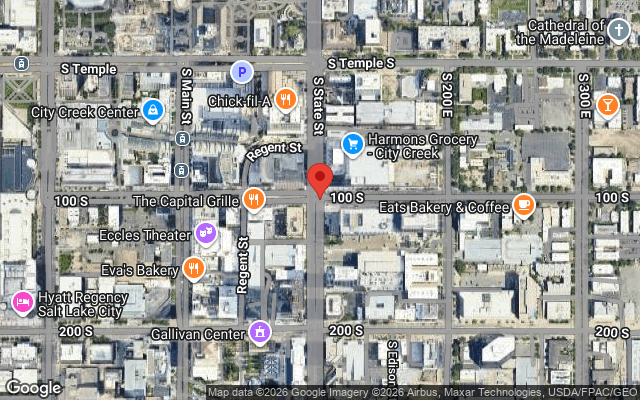

Static map: 190,402 bytes


In [15]:
# Nearest roads
roads = gm.nearest_roads(loc['lon'], loc['lat'])
print(f"Nearest roads: {len(roads)} segments")
for r in roads:
    print(f"  ({r['lat']:.5f}, {r['lon']:.5f})")

# Static map
static = gm.get_static_map(
    loc['lon'], loc['lat'],
    zoom=16, size="640x400", maptype="hybrid",
    markers=[(loc['lon'], loc['lat'])],
)
if static:
    display(IPImage(data=static, width=640))
    print(f"Static map: {len(static):,} bytes")

---
## Summary

| Category | Functions | API Key |
|---|---|---|
| Geocoding | `geocode`, `reverse_geocode`, `validate_address` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Places | `search_places`, `search_nearby`, `get_place_photo` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Street View | `streetview_metadata`, `streetview_image`, `streetview_panorama`, `streetview_html` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| AI Analysis | `interpret_image` (modes: streetview / satellite-map / hybrid-map / roadmap / terrain), `label_image`, `label_streetview` | `GEMINI_API_KEY` |
| Segmentation | `segment_image` (modes: streetview / aerial-urban / aerial-landcover / aerial-mixed / buildings / trees), `segment_streetview` | None (local model, first-run downloads) |
| **Rigorous inventory** | **`inventory_area`** — design-based sampling (SRS / systematic / stratified), dedup+refill, batched Gemini, Wilson + bootstrap CIs, kappa/ICC reliability, HTML/JSON/MD/DataFrame outputs | `GOOGLE_MAPS_PLATFORM_API_KEY` + `GEMINI_API_KEY` |
| Elevation | `get_elevation`, `get_elevations`, `get_elevation_along_path` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Environment | `get_air_quality`, `get_solar_insights`, `get_timezone` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Maps & Roads | `get_static_map`, `snap_to_roads`, `nearest_roads` | `GOOGLE_MAPS_PLATFORM_API_KEY` |